In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from tqdm.notebook import tqdm
import pickle
from itertools import combinations

import utils_string as uts
import utils as ut

# String model with fixed time of maximum expansion

### Testing the generation of strings with desired recruited number and affinities

In [2]:
R = 500
string_model = uts.TT_string(N_tot=10**6, L_string=30, N_recruit=100)

logts_mean, logts_std, N_recrs = [], [], []
progress = tqdm(total=R)
for _ in range(R):
    recruit_strings, h_recruit = string_model.gen_and_recruit_string()
    logtaus = string_model.get_logtau(h_recruit)
    logts_mean.append(np.mean(logtaus))
    logts_std.append(np.std(logtaus))
    N_recrs.append(len(h_recruit))
    progress.update(1)

  0%|          | 0/500 [00:00<?, ?it/s]

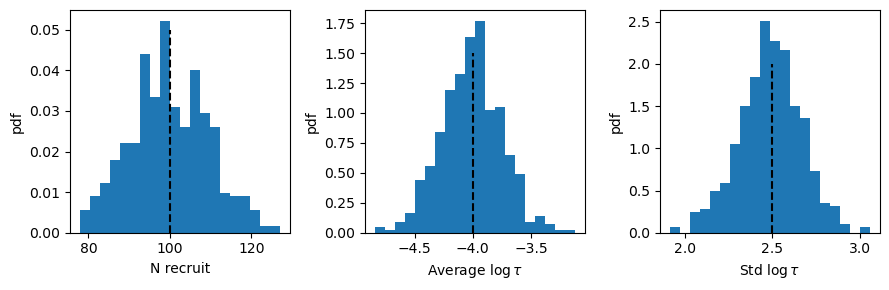

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(9,3))

ax1.set_xlabel('N recruit')
ax1.set_ylabel('pdf')
ax1.hist(N_recrs, bins=20, density=True)
Nr = string_model.N_recr
ax1.plot([Nr, Nr], [0, 1/np.sqrt(Nr)/2], c='k', ls='--')

ax2.set_xlabel(r'Average $\log \tau$')
ax2.set_ylabel('pdf')
ax2.hist(logts_mean, bins=20, density=True)
ax2.plot([-4, -4], [0, 1.5], c='k', ls='--')

ax3.set_xlabel(r'Std $\log \tau$')
ax3.set_ylabel('pdf')
ax3.hist(logts_std, bins=20, density=True)
ax3.plot([2.5, 2.5], [0, 2], c='k', ls='--')

plt.tight_layout()

### Genereting an ensemble of recruited binary clones at given string-model parameters

Use the script **string_model_gen_repertoire.py**

#### Checking some examples of trajectories given the generated strings

In [3]:
out_dir = 'out_data/string_model/'
str_name = 'gamma=2.0_L=30'
mean_logtau, std_logtau = -4, 2.5
alpha0, beta0 = 1e-6, 0.9


with open(out_dir + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)
pars = pd.read_csv(out_dir + f'string_pars_{str_name}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])

logtau_ens = []
for i, strings in enumerate(string_ens):
    h_dists = uts.comp_h_dist(strings, np.zeros(len(strings[0])))
    logtau_ens.append(string_model.get_logtau(h_dists, mean_logtau, std_logtau))

    
# Sampling taus from lognormal with default parameters
tau_samp = ut.tau_sampler_lognorm(logmean=mean_logtau, logstd=std_logtau)

# Defining the default realistic paramters
taus = np.exp(logtau_ens[0])
TT_pars = ut.TT_params(taus, alpha0=alpha0, beta0=beta0)

# Integration parameters
traj_steps, dt = 50, 0.005
t_steps = int(30 / dt)

times, T_trajs, P_trajs, S_trajs = ut.run_setting(TT_pars, tau_samp, t_steps, dt, traj_steps=traj_steps)

extinct_traj = np.all(T_trajs <= 1, axis=0)
T_tot = np.sum(T_trajs[:,~extinct_traj], axis=1)
t_max = times[np.argmax(T_tot)]
print(t_max)

11.25


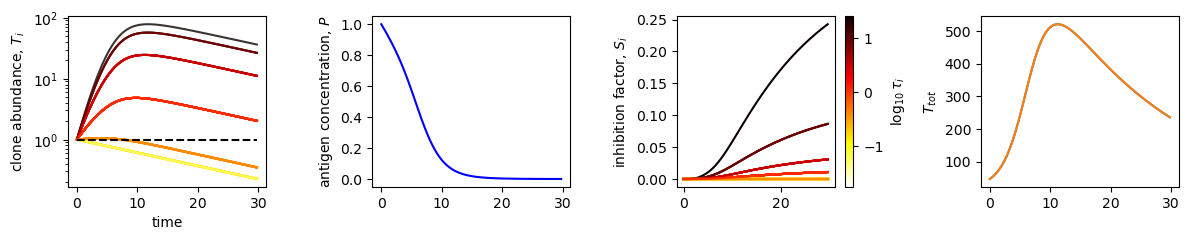

In [4]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(12,2.5))

ax1.set_yscale('log')
ax1.set_xlabel('time')
ax1.set_ylabel(r'clone abundance, $T_i$')
cmap = mpl.colormaps.get_cmap('hot_r')
cmap_norm = plt.Normalize(vmin=min(np.log10(taus)), vmax=max(np.log10(taus)))
for i, Ts in enumerate(T_trajs.T):
    color = cmap(cmap_norm(np.log10(taus[i])))
    ax1.plot(times, Ts, c=color, alpha=0.8)
    
#ax1.set_ylim(0.9, np.max(T_trajs)*1.1)

#ax1.plot(times, T_tot, c='b', label=r'$\sum_i T_i$')
ax1.plot(times, np.ones(len(times)), c='k', ls='--')
#ax1.legend()

ax2.set_ylabel(r'antigen concentration, $P$')
ax2.plot(times, P_trajs, c='b')

ax3.set_ylabel(r'inhibition factor, $S_i$')
for i, Ss in enumerate(S_trajs.T):
    color = cmap(cmap_norm(np.log10(taus[i])))
    ax3.plot(times, Ss, c=color)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=cmap_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax3, label=r'$\log_{10} \tau_i$')

plt.plot(times, np.array(T_tot))

ax4.set_ylabel(r'$T_{tot}$')
min_t = np.argmin(T_trajs[-1])
ax4.plot(times, np.array(T_tot), label=r'$\sum T_i$')
#ax4.plot(times, np.array(T_tot)-100*T_trajs[:,min_t], label=r'$\sum T_i - N_{recr} * T_{min}$')
#ax4.legend()
plt.tight_layout()

### Computing beta0 at constant time of max expansion 

Use the script **string_model_get_b0s.py**

35


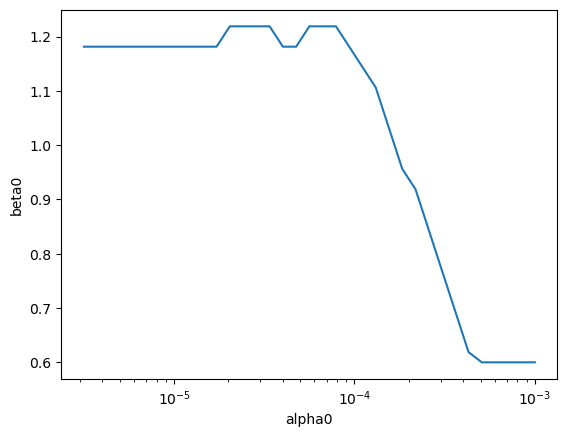

In [6]:
out_dir = 'out_data/string_model/'
name = 'gamma=2.0_L=30_meanlt=-4_stdlt=2.5'

with open(out_dir + f'a0s_b0s_{name}.pkl', 'rb') as f:
    alpha0s, beta0s = pickle.load(f)
print(len(alpha0s))

plt.xscale('log')
plt.xlabel('alpha0')
plt.ylabel('beta0')
plt.plot(alpha0s, beta0s)

### Analysis of the generated clonotype abundances and coverage

Use the script **string_model_gen_trajs.py**

In [3]:
out_dir = 'out_data/string_model/'
str_name = 'gamma=2.0_L=40'
name = str_name + '_meanlt=-4_stdlt=2.5'

with open(out_dir + f'string_ens_{str_name}.pkl', 'rb') as f:
    string_ens = pickle.load(f)

with open(out_dir + f'a0s_b0s_{name}.pkl', 'rb') as f:
    alpha0s, beta0s = pickle.load(f)


with open(out_dir + f'Ts_final_{name}.pkl', 'rb') as f:
    string_ids_ens, Ts_final_ens, x_maxs_ens, n_xmax_ens = pickle.load(f)

pars = pd.read_csv(out_dir + f'pars_{name}.tsv', sep='\t', header=None, index_col=0)[1].to_dict()
Rt = int(pars['R_traj'])
L = int(pars['L_string'])

string_model = uts.TT_string(N_tot=pars['N_tot'], L_string=int(pars['L_string']), N_recruit=pars['N_recruit'])
hs_ens = [uts.comp_h_dist(strings, np.zeros(len(strings[0]))) for strings in string_ens]
mean_lt, std_lt = pars['mean_logtau'], pars['std_logtau']
logtau_ens = [string_model.get_logtau(hs, mean_lt, std_lt) for hs in hs_ens]

In [4]:
pars

{'L_string': 40.0,
 'N_tot': 10000000.0,
 'N_recruit': 100.0,
 'D0': 4.087866292932057,
 'mean_logtau': -4.0,
 'std_logtau': 2.5,
 'R_beta0': 100.0,
 't_T_max': 9.0,
 't_T_max_tol': 0.05,
 'R_traj': 1000.0,
 'mem_time': 30.0,
 'dt': 0.005}

In [5]:
n_muts = [0, 2, 4, 8, 12, 16, 20]
max_R_n_muts = 10

covers_min, covers_avh, covers_activ = [], [], []
T_tots, inv_simpss, richs = [], [], []
progress = tqdm(total=len(alpha0s))
for i in range(len(alpha0s)):

    strings = [string_ens[k] for k in string_ids_ens[i]]
    logtaus = [logtau_ens[k] for k in string_ids_ens[i]]
    covers_min_aux, covers_avh_aux, covers_activ_aux = [], [], []

    for n_mut in n_muts:

        cs_min_aux, cs_avh_aux, cs_activ_aux = [], [], []
        R_count = 0
        for mut_ids in combinations(np.arange(L), n_mut):

            a_mut = np.zeros(L)
            a_mut[list(mut_ids)] = 1
            h_dists = [uts.comp_h_dist(strings[k], a_mut) for k in range(Rt)]
            taus = [np.exp(string_model.get_logtau(hs, mean_lt, std_lt)) for hs in h_dists]
            cs_min_aux.extend([uts.compute_coverage_min(h_dists[k], Ts_final_ens[i][k]) for k in range(Rt)])
            cs_avh_aux.extend([uts.compute_coverage_avh(h_dists[k], Ts_final_ens[i][k]) for k in range(Rt)])
            cs_activ_aux.extend([uts.compute_coverage_activ(taus[k], Ts_final_ens[i][k]) for k in range(Rt)])

            R_count += 1
            if R_count > max_R_n_muts:
                break

        covers_min_aux.append(np.mean(cs_min_aux))
        covers_avh_aux.append(np.mean(cs_avh_aux))
        covers_activ_aux.append(np.mean(cs_activ_aux))

    covers_min.append(covers_min_aux)
    covers_avh.append(covers_avh_aux)
    covers_activ.append(covers_activ_aux)

    T_tots.append(np.mean( [np.sum(Ts_final_ens[i][r]) for r in range(Rt)] ))
    inv_simpss.append(uts.compute_inv_simps(Ts_final_ens[i]))
    richs.append(uts.compute_richness(Ts_final_ens[i], strings))
    progress.update(1)
    
covers_min, covers_avh, covers_activ = np.array(covers_min), np.array(covers_avh), np.array(covers_activ)

  0%|          | 0/35 [00:00<?, ?it/s]

/home/andrea/Research/Immuno/TT-inhibition/utils_string.py:146: RuntimeWarning: divide by zero encountered in scalar divide
  inv_simps = np.array([1 / np.sum(freqs**2) for freqs in T_freqs_mat])


NameError: name 'pars' is not defined

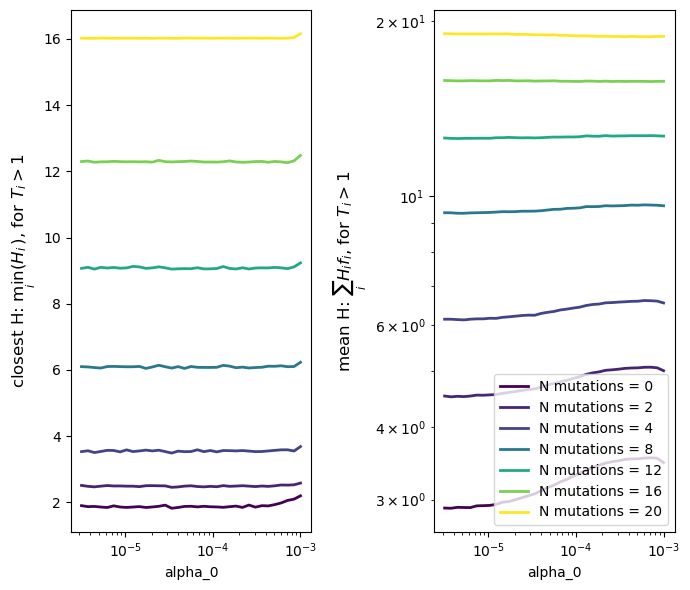

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(7, 6))
cmap = mpl.colormaps.get('viridis')

for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.set_xlabel('alpha_0')

ax2.set_yscale('log')

ax1.set_ylabel(r'closest H: $\min_i (H_i)$, for $T_i > 1$', fontsize=12)
ax2.set_ylabel(r'mean H: $\sum_i H_i f_i$, for $T_i > 1$', fontsize=12)
for i, n_mut in enumerate(n_muts):
    c = cmap(n_mut/max(n_muts))
    ax1.plot(alpha0s, covers_min[:,i], label=f'N mutations = {n_mut}', c=c, lw=2)
    ax2.plot(alpha0s, covers_avh[:,i], label=f'N mutations = {n_mut}', c=c, lw=2)
ax2.legend()

plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage/{name}_coverage.svg', facecolor='w')

In [ ]:
max_n_mut = 10
max_R_n_muts = 20


covers_min = []
progress = tqdm(total=len(alpha0s))
for i in range(len(alpha0s)):
    strings = [string_ens[k] for k in string_ids_ens[i]]
    logtaus = [logtau_ens[k] for k in string_ids_ens[i]]
    covers_min_aux = []

    for n_mut in range(1, max_n_mut):

        cs_min_aux = []
        R_count = 0
        for mut_ids in combinations(np.arange(L), n_mut):

            a_mut = np.zeros(L)
            a_mut[list(mut_ids)] = 1
            h_dists = [uts.comp_h_dist(strings[k], a_mut) for k in range(Rt)]
            cs_min_aux.extend([compute_coverage_min(h_dists[k], Ts_final_ens[i][k]) for k in range(Rt)])

            R_count += 1
            if R_count > max_R_n_muts:
                break

        covers_min_aux.append(np.mean(cs_min_aux))

    covers_min.append(covers_min_aux)
    progress.update(1)
    
covers_min = np.array(covers_min)

  0%|          | 0/35 [00:00<?, ?it/s]

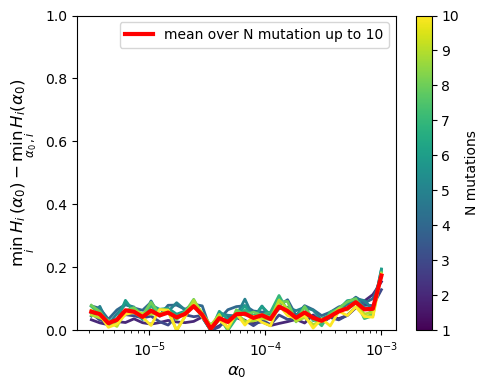

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,4))

map = mpl.colormaps.get('viridis')

ax.set_xscale('log')
ax.set_ylabel(r'$\min_i \, H_i(\alpha_0) - \min_{\alpha_0,i} \, H_i(\alpha_0)$', fontsize=12)
ax.set_xlabel(r'$\alpha_0$', fontsize=12)
for i, n_mut in enumerate(range(1,max_n_mut)):
    c = cmap(n_mut/(max_n_mut-1))
    norm = np.min(covers_min[:,i])
    ax.plot(alpha0s, covers_min[:,i]-norm, c=c, lw=2)

norms = np.min(covers_min[:,:max_n_mut], axis=0)
mean_h_min = np.mean(covers_min[:,:max_n_mut] - norms[np.newaxis,:], axis=1)
ax.plot(alpha0s, mean_h_min, label=f'mean over N mutation up to {max_n_mut}', c='r', lw=3)

norm_cb = plt.Normalize(vmin=1, vmax=max_n_mut)
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_cb), label='N mutations', ax=ax)
plt.legend()
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage/{name}_coverage_rescaled.svg', facecolor='w')

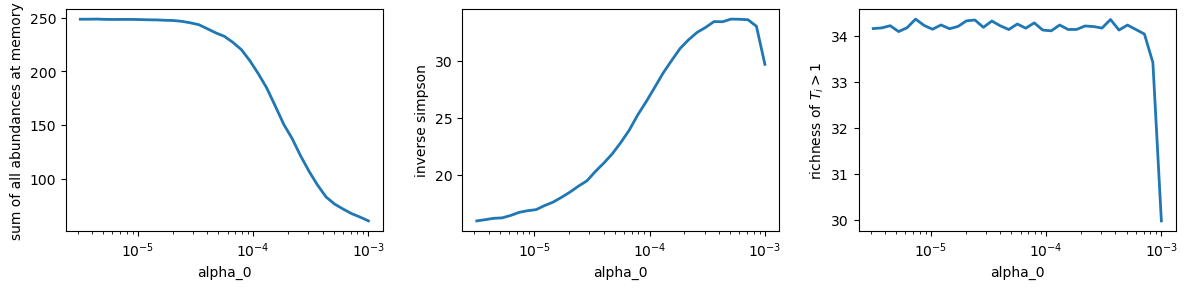

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,3))

for ax in (ax1, ax2, ax3):
    ax.set_xscale('log')
    ax.set_xlabel('alpha_0')

ax1.set_ylabel('sum of all abundances at memory')
ax1.plot(alpha0s, np.array(T_tots), lw=2)
#ax1.set_ylim(1, max(factors)+0.2)

ax2.set_ylabel('inverse simpson')
ax2.plot(alpha0s, inv_simpss, lw=2)

ax3.set_ylabel('richness of $T_i>1$')
ax3.plot(alpha0s, richs, lw=2)

plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage/{name}_tradeoff.svg', facecolor='w')

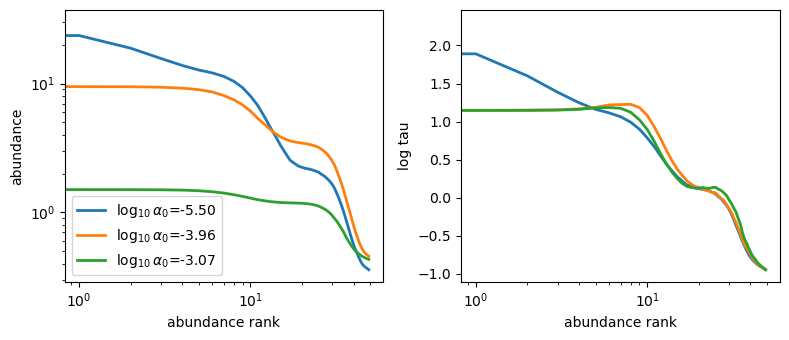

In [ ]:
i_alphas = [0, 21, 33]
max_rank = 50

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.set_xlabel('abundance rank')
ax1.set_ylabel('abundance')
ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlabel('abundance rank')
ax2.set_ylabel('log tau')
ax2.set_xscale('log')

for i, i_alpha in enumerate(i_alphas):

    av_T_rank, av_lt_rank, T_rank_count = np.zeros(max_rank), np.zeros(max_rank),  np.zeros(max_rank)
    for r, Ts in enumerate(Ts_final_ens[i_alpha]):
        rank = np.argsort(Ts)[::-1][:min(len(Ts), max_rank)]
        av_T_rank += np.array(Ts[rank])
        av_lt_rank += np.array(logtau_ens[string_ids_ens[i_alpha][r]])[rank]
        T_rank_count += 1
    av_T_rank /= T_rank_count
    av_lt_rank /= T_rank_count

    lab = r'$\log_{10}\alpha_0$=%3.2f'%np.log10(alpha0s[i_alpha])
    ax1.plot(np.arange(max_rank), av_T_rank, label=lab, lw=2)
    ax2.plot(np.arange(max_rank), av_lt_rank, label=lab, lw=2)

ax1.legend()

plt.tight_layout()
plt.savefig(f'plots/evo_model_coverage/{name}_abundance-affinity.svg', facecolor='w')